# Difusión condicionada por texto

In [13]:
from pathlib import Path
import random
import json
from diffusers import StableDiffusionPipeline
import numpy
import torch
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
import numpy as np
from PIL import Image

In [2]:
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


## Extracción de prompts

In [3]:

captions_path  = Path('annotations') / 'captions_val2017.json'
instances_path = Path('annotations') / 'instances_val2017.json'

SUPERCATEGORIA = 'person' 

random.seed(33443)  # Para reproducibilidad

def extraer_prompts_dominio(supercategoria, max_prompts):

    with open(instances_path, 'r', encoding='utf-8') as f:
        inst = json.load(f)
    with open(captions_path, 'r', encoding='utf-8') as f:
        caps = json.load(f)

    cat_ids = {c['id'] for c in inst['categories'] if c['supercategory'] == supercategoria}
    img_ids = {a['image_id'] for a in inst['annotations'] if a['category_id'] in cat_ids}
    prompts = [a['caption'] for a in caps['annotations'] if a['image_id'] in img_ids]
    prompts = [p.strip() for p in prompts if p.strip()]
    random.shuffle(prompts)
    return prompts[:max_prompts]


prompts_dominio = extraer_prompts_dominio\
    (SUPERCATEGORIA, max_prompts=13471)
print('Prompts extraídos:', len(prompts_dominio))
for i, p in enumerate(prompts_dominio[:5], 1):
    print(f'{i}. {p}')


Prompts extraídos: 13471
1. Five people sitting on a subway checking their phones
2. A man doing a skateboard trick on some stairs.
3. a person flying backwards on skis over water
4. A gathering of people and several motor bikes.
5. MOTOR CROSS BIKE AND RIDER IN THE AIR DOING TRICKS


## Generación latente

In [4]:
modelo = "runwayml/stable-diffusion-v1-5"
dtype =  torch.float32

pipe = StableDiffusionPipeline.from_pretrained(modelo)
pipe = pipe.to(device)
pipe.enable_attention_slicing()

if device == "cuda":
    pipe.enable_vae_slicing()

pipe.safety_checker = None

print(f"Pipeline cargado en {device} con dtype {dtype}")

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 507.77it/s] 2.59it/s]
CLIPTextModel LOAD REPORT from: /home/mateo/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 441.87it/s] 2.23it/s]
StableDiffusionSafetyChecker LOAD REPORT from: /home/mateo/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |

Pipeline cargado en cuda con dtype torch.float32


/home/mateo/VPCII_2/VPCII/practica_2/.venv/lib/python3.13/site-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [5]:
g     = torch.Generator(device=device).manual_seed(42)
imagenes = []
for prompt in prompts_dominio[:1]:
    image = pipe(prompt, num_inference_steps=30, generator=g).images[0]
    imagenes.append(image)

100%|██████████| 30/30 [06:31<00:00, 13.07s/it]


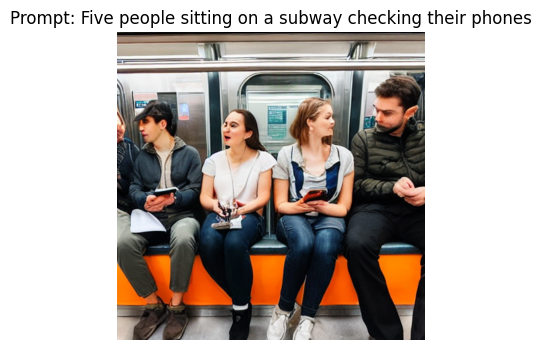

In [ ]:
# Representar las imagenes generadas
fig, axs = plt.subplots(1, 1, figsize=(20, 4))

ax.imshow(img)
ax.set_title(f'Prompt {prompts_dominio[i-1]}')
ax.axis('off')
plt.show()

# Ajuste classifier free guidance

In [8]:
CFG_valores = [2,7,12,16,20,30]

imagenes_cfg = []
for prompt in prompts_dominio[:1]:
    for cfg in CFG_valores:
        image = pipe(prompt, num_inference_steps=30, guidance_scale=cfg, generator=g).images[0]
        imagenes_cfg.append(image)

100%|██████████| 30/30 [06:26<00:00, 12.88s/it]


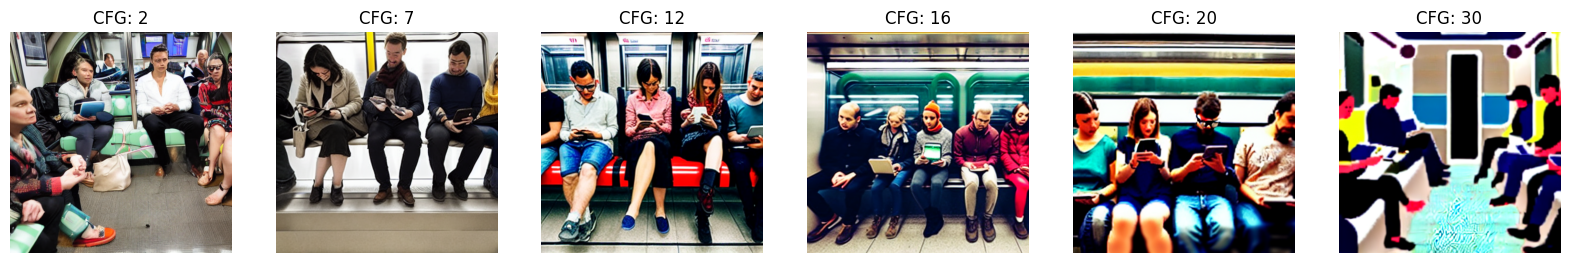

In [16]:
# Representar las imagenes generadas
fig, axs = plt.subplots(1, 6, figsize=(20, 4))
for i, (ax, img) in enumerate(zip(axs, imagenes_cfg), 1):
    ax.imshow(img)
    ax.set_title(f'CFG: {CFG_valores[i-1]}')
    ax.axis('off')
plt.show()

## CLIP Score

In [15]:
from transformers import CLIPProcessor, CLIPModel
import numpy as np

model_id = 'openai/clip-vit-base-patch32'
clip_model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)

prompt_clip = prompts_dominio[0] if prompts_dominio else 'a dog running on grass'
scores = []

for img in imagenes_cfg:
    # imagenes_cfg ya contiene objetos PIL.Image generados por Stable Diffusion.
    inputs = processor(text=[prompt_clip], images=img, return_tensors='pt', padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.inference_mode():
        out = clip_model(**inputs)
        txt = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True)
        im = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        scores.append(float((txt * im).sum(dim=-1).item()))

media = float(np.mean(scores)) if scores else float('nan')
std = float(np.std(scores)) if scores else float('nan')

for cfg, score in zip(CFG_valores, scores):
    print(f'CFG: {cfg} | CLIP Score: {score:.4f}')

print(f'CLIP media: {media:.4f}')
print(f'CLIP std  : {std:.4f}')


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 7370.45it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CFG: 2 | CLIP Score: 0.3219
CFG: 7 | CLIP Score: 0.3339
CFG: 12 | CLIP Score: 0.3285
CFG: 16 | CLIP Score: 0.3457
CFG: 20 | CLIP Score: 0.3280
CFG: 30 | CLIP Score: 0.3063
CLIP media: 0.3274
CLIP std  : 0.0119
